In [1]:
import numpy as np
from numpy.linalg import cholesky, solve
import arviz as az
from scipy.stats import gaussian_kde
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel, Hyperparameter
import seaborn as sns
import pytensor
import pytensor.tensor as pt
# pytensor.config.cxx = ""          # disable C compilation
import pymc as pm
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.colors import Normalize

set_matplotlib_formats('pdf', 'svg')
sns.set(font_scale=1.3)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

# Generate data

In [2]:
W_orig = np.load("Dataset/W.npy")  # Our FK-table
xgrid = np.load("Dataset/xgrid.npy")  # Our x-grid
c_yy_orig = np.load("Dataset/c_yy.npy")  # Covariance matrix
y_real = np.load("Dataset/y_real.npy")  # Real data differences
q2_vals = np.load("Dataset/q2_vals.npy")  # Corresponding Q2 values
y_theory = np.load("Dataset/y_theory.npy")  # Corresponding y0 based on W @ (xt3_true) with xt3_true from NNPDF4.0
f0_vals = np.load("Dataset/xt3_true.npy") #Corresponding to the underlying law f0

# test data
f0_test = np.load('Dataset/xt3_test.npy')
xgrid_test = np.load('Dataset/xgrid_test.npy')

# print(y_theory)

In [3]:
rng = np.random.default_rng(seed=451)  # you can set seed if you want reproducible “data”
noise = rng.multivariate_normal(mean=np.zeros(len(y_theory)), cov=c_yy_orig)

y_pseudo_orig = y_theory + noise

x_star = np.linspace(0, 1, 400) 

In [4]:
# rescale data, centralize it
s = np.std(y_pseudo_orig)  # typical scale of observable

y_pseudo  = y_pseudo_orig / s
c_yy = c_yy_orig / s**2
W  = W_orig / s        # because y = W f

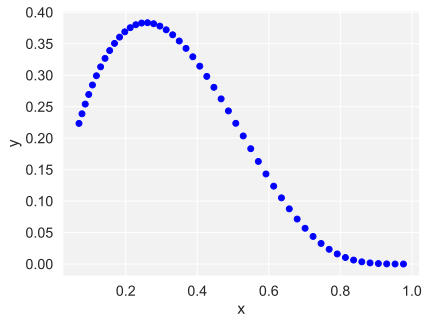

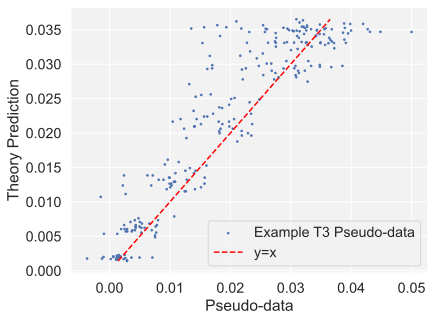

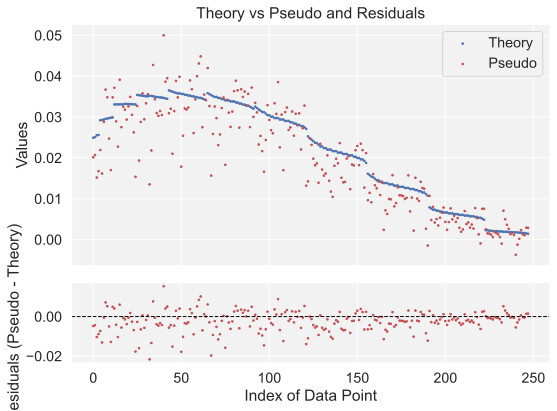

In [7]:
plt.scatter(xgrid, f0_vals, label="Example f0", color="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

plt.scatter(y_pseudo_orig, y_theory, label="Example T3 Pseudo-data",s=3)
plt.plot([min(y_theory), max(y_theory)],[min(y_theory), max(y_theory)], color="red", linestyle="--", label="y=x")

plt.legend()
plt.xlabel("Pseudo-data")
plt.ylabel("Theory Prediction")
plt.show()
plt.close()

residuals = y_pseudo_orig - y_theory

# Create two vertically stacked subplots (shared x-axis)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 6), 
    gridspec_kw={'height_ratios': [3, 1]}, 
    sharex=True
)

# --- Top plot: theory vs pseudo
ax1.scatter(np.arange(len(y_theory)), y_theory, s=3, label='Theory')
ax1.scatter(np.arange(len(y_pseudo_orig)), y_pseudo_orig, s=3, label='Pseudo',color='r')
ax1.legend()
ax1.set_ylabel("Values")
ax1.set_title("Theory vs Pseudo and Residuals")

# --- Bottom plot: residuals
ax2.scatter(np.arange(len(residuals)), residuals, s=3, color='r')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel("Index of Data Point")
ax2.set_ylabel("Residuals (Pseudo - Theory)")

plt.tight_layout()
plt.show()


look int separate x grid values, what about pseudo data and cov matrix 

In [8]:
print(np.min(xgrid), np.max(xgrid))

0.06925758308452344 0.9764562912534639


# Construct GP using a Gibbs kernel for t3 fitting

## Construct RBF kernel

Include $x^\alpha$ scaling as used in Gibbs kernel

In [5]:
class RBFKernel1D(Kernel):
    """
    1D RBF kernel with optional small-x rescaling:

        K0(x,y) = sigma2 * exp( - (x-y)^2 / (2*ell^2) )
        K(x,y)  = (x^alpha)(y^alpha) * K0(x,y)

    Trainable hyperparameters (theta):
        theta = [alpha, log_ell, log_sigma2]
    """

    def __init__(
        self,
        alpha=-0.2,
        ell=1.0,
        sigma2=1.0,
        alpha_bounds=(-1.0, 0.0),
        ell_bounds=(1e-6, 1e6),
        sigma2_bounds=(1e-6, 1e6),
        x_floor=1e-12,
    ):
        self.alpha = float(alpha)
        self.ell = float(ell)
        self.sigma2 = float(sigma2)

        self.alpha_bounds = alpha_bounds
        self.ell_bounds = ell_bounds
        self.sigma2_bounds = sigma2_bounds
        self.x_floor = float(x_floor)

    @property
    def hyperparameter_alpha(self):
        return Hyperparameter("alpha", "numeric", self.alpha_bounds)

    @property
    def hyperparameter_ell(self):
        return Hyperparameter("ell", "numeric", self.ell_bounds)

    @property
    def hyperparameter_sigma2(self):
        return Hyperparameter("sigma2", "numeric", self.sigma2_bounds)

    @property
    def theta(self):
        # NOTE: alpha is stored directly; ell and sigma2 in log-space
        return np.array([self.alpha, np.log(self.ell), np.log(self.sigma2)])

    @theta.setter
    def theta(self, theta):
        self.alpha = float(theta[0])
        self.ell = float(np.exp(theta[1]))
        self.sigma2 = float(np.exp(theta[2]))

    @property
    def bounds(self):
        return np.array(
            [
                self.alpha_bounds,
                np.log(self.ell_bounds),
                np.log(self.sigma2_bounds),
            ],
            dtype=float,
        )

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        if X.shape[1] != 1:
            raise ValueError("Only 1D inputs (n,1).")
        Y = X if Y is None else np.atleast_2d(Y)
        if Y.shape[1] != 1:
            raise ValueError("Only 1D inputs (m,1).")

        x = X[:, 0][:, None]          # (n,1)
        y = Y[:, 0][None, :]          # (1,m)

        diff2 = (x - y) ** 2
        ell2 = max(self.ell, 1e-300) ** 2

        # base RBF part K0
        expo0 = np.exp(-0.5 * diff2 / ell2)

        K0 = self.sigma2 * expo0

        # small-x rescaling
        x_safe = np.maximum(x, self.x_floor)
        y_safe = np.maximum(y, self.x_floor)
        scale = (x_safe ** self.alpha) * (y_safe ** self.alpha)

        K = scale * K0

        if not eval_gradient:
            return K

        # ---- gradients w.r.t [alpha, log_ell, log_sigma2]

        eps = 1e-300  # numerical guard (keep if you want safety)

        # alpha
        logx = np.log(x_safe)
        logy = np.log(y_safe)
        dK_dalpha = K * (logx + logy)

        # sigma2 (K linear in sigma2)
        sigma2_safe = max(self.sigma2, eps)
        dK_dsigma2 = K / sigma2_safe

        # ell (raw)
        ell_safe = max(self.ell, eps)
        ell2 = ell_safe * ell_safe
        dK_dell = K * diff2 / (ell2 * ell_safe)   # = K * diff2 / ell^3

        grad = np.stack([dK_dalpha, dK_dell, dK_dsigma2], axis=2)
        return K, grad

    def diag(self, X):
        X = np.atleast_2d(X)
        x = np.maximum(X[:, 0], self.x_floor)
        # For x=y: exp(0)=1, so diag = sigma2 * x^(2 alpha)
        return self.sigma2 * (x ** (2 * self.alpha))

    def is_stationary(self):
        # Base RBF is stationary, but the x^alpha scaling makes it non-stationary
        return False


## Implementation

In [6]:
X_train = xgrid.reshape(-1, 1)   # (N, 1)
X_star  = x_star.reshape(-1, 1)    # (N*,1)

kern = RBFKernel1D(alpha=-0.2, ell=2, sigma2=0.3)

Kxx   = kern(X_train)                 # (N, N)
Ksx   = kern(X_star,  X_train)        # (N*, N)  == K_{x* x}
Kxs   = kern(X_train,  X_star)        # (N, N*)  == K_{x x*}
Kss   = kern(X_star,  X_star)         # (N*, N*) == K_{x* x*}



In [7]:
def log_marginal_likelihood(theta, x_train, FK, CY, y, delta):
    """
    theta = (alpha, l0, sigma2)
    returns log p(y | theta)
    """
    X_train = x_train.reshape(-1, 1)

    #theta ordering: alpha, l, sigma2

    # alpha, l0, sigma2 = theta
    # kern = GibbsKernel1D(alpha=alpha, l0=l0, sigma2=sigma2, delta=1e-5)
    
    alpha, l0, sigma2 = theta    
    kern = RBFKernel1D(alpha=alpha, ell=l0, sigma2=sigma2)

    Kxx = kern(X_train)  # (N, N)

    # data-space covariance CYT
    Cyt = FK @ Kxx @ FK.T + CY
    Cyt = Cyt + 1e-10*np.eye(Cyt.shape[0])  # jitter

    # Cholesky
    # L = cholesky(Cyt)
    try:
        L = np.linalg.cholesky(Cyt)
    except np.linalg.LinAlgError:
        return -np.inf   # invalid θ region

    # quadratic term: y^T CYT^{-1} y
    v = solve(L, y)
    quad = v @ v

    # log determinant
    # logdet = np.sum(np.log(np.diag(Cyt)))
    logdet = 2.0 * np.sum(np.log(np.diag(L)))

    n = y.shape[0]
    logp = -0.5*quad - 0.5*logdet - 0.5*n*np.log(2*np.pi)
    return logp

def log_prior(theta):
    alpha, l0, sigma2 = theta
    if not (-1.0 < alpha < 0.0):
        return -np.inf
    if not (0.0 < l0 < 10.0):
        return -np.inf
    if not (0.0 < sigma2 < 100.0):
        return -np.inf
    return 0.0

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_marginal_likelihood(
        theta=theta,
        x_train=xgrid,
        FK=W,
        CY=c_yy,
        y=y_pseudo,
        delta=1e-5
    )

In [8]:
# parameter scan for sampling with NUTS
alphas = np.linspace(-0.999, -0.05, 25)
l0s    = np.logspace(np.log10(0.03), np.log10(5.0), 25)
sig2s  = np.logspace(np.log10(0.05), np.log10(200.0), 25)

best_lp, best_th = -np.inf, None
for a in alphas:
    for l0 in l0s:
        for s2 in sig2s:
            lp = log_posterior((a,l0,s2))
            if lp > best_lp:
                best_lp, best_th = lp, (a,l0,s2)

print(best_th, best_lp)

(-0.3267916666666667, 0.31294541878833726, 0.049999999999999996) -82.69432172450496


## NUTS

In [9]:
delta = 1e-5
x_floor = 1e-12

X_train_t = pt.constant(xgrid.reshape(-1, 1))  # (Ngrid,1)
FK_t      = pt.constant(W)                    # (Ndat, Ngrid)
CY_t      = pt.constant(c_yy)                 # (Ndat, Ndat)
y_t       = pt.constant(y_pseudo)             # (Ndat,)

In [10]:
def Kxx_rbf_pt(alpha, ell, sigma2):
    """
    Returns Kxx in PyTensor for RBF base kernel.
    Inputs are PyTensor scalars alpha, ell, sigma2.

    K(x,y) = sigma2 * (x^alpha)(y^alpha) * exp( -(x-y)^2 / (2*ell^2) )
    """

    x = X_train_t[:, 0][:, None]   # (N,1)
    y = X_train_t[:, 0][None, :]   # (1,N)

    # constant lengthscale ell
    ell_safe = pt.maximum(ell, 1e-12)
    diff2 = (x - y)**2

    K0 = sigma2 * pt.exp(-0.5 * diff2 / (ell_safe**2))

    # small-x rescaling x^alpha y^alpha
    x_safe = pt.maximum(x, x_floor)
    y_safe = pt.maximum(y, x_floor)
    scale = (x_safe**alpha) * (y_safe**alpha)

    return scale * K0


def log_marginal_likelihood_rbf_pt(alpha, ell, sigma2):
    """
    PyTensor version of log p(y | theta) for RBF kernel.
    theta = (alpha, ell, sigma2).
    """
    Kxx = Kxx_rbf_pt(alpha, ell, sigma2)

    CYT = FK_t @ Kxx @ FK_t.T + CY_t
    CYT = 0.5 * (CYT + CYT.T)

    CYT = CYT + 1e-10 * pt.eye(CYT.shape[0])  # jitter

    # Cholesky
    L = pt.linalg.cholesky(CYT)

    # quad term: y^T CYT^{-1} y
    v = pt.linalg.solve_triangular(L, y_t, lower=True)
    quad = pt.dot(v, v)

    # logdet
    logdet = 2.0 * pt.sum(pt.log(pt.diag(L)))

    n = y_t.shape[0]
    logp = -0.5 * quad - 0.5 * logdet - 0.5 * n * pt.log(2 * np.pi)
    return logp


def log_prior_rbf_pt(alpha, ell, sigma2):
    """
    Box prior:
      alpha in (-1, 0)
      ell   in (0, 10)
      sigma in (0, 10)  <=> sigma2 in (0, 100)
    """
    sigma = pt.sqrt(sigma2)

    in_bounds = (
        (alpha > -1.0) & (alpha < 0.0) &
        (ell > 0.0) & (ell < 10.0) &
        (sigma > 0.0) & (sigma < 10.0)
    )
    return pt.switch(in_bounds, 0.0, -np.inf)


def log_posterior_rbf_pt(alpha, ell, sigma2):
    return log_prior_rbf_pt(alpha, ell, sigma2) + \
           log_marginal_likelihood_rbf_pt(alpha, ell, sigma2)


In [11]:
th = (-0.3, 5.0, 0.15)
alpha, l0, s2 = th

X_train = xgrid.reshape(-1, 1)

kern_np = RBFKernel1D(alpha=alpha, ell=l0, sigma2=s2)


# 2) then call it on arrays to get Kxx
K_np = kern_np(X_train, X_train)

# evaluate PyTensor graph at same theta
alpha_sym = pt.scalar("alpha")
l0_sym    = pt.scalar("l0")
s2_sym    = pt.scalar("s2")

# Build symbolic Kxx
K_pt_expr = Kxx_rbf_pt(alpha_sym, l0_sym, s2_sym)

# Compile function that takes (alpha,l0,s2) and returns Kxx
K_pt_fn = pytensor.function([alpha_sym, l0_sym, s2_sym], K_pt_expr)

# Evaluate at the same theta
K_pt = K_pt_fn(alpha, l0, s2)

rel_diff = np.linalg.norm(K_np - K_pt) / np.linalg.norm(K_np)
print("relative diff:", rel_diff)


relative diff: 8.938257915219535e-17


In [12]:
with pm.Model() as model:
    alpha = pm.Uniform("alpha", -1.0, 0.0)
    l0    = pm.Uniform("l0", 0.0, 10.0)
    sigma = pm.Uniform("sigma", 0.0, 10.0)
    sigma2 = pm.Deterministic("sigma2", sigma**2)

    # pm.Potential("posterior_theta", log_posterior_pt(alpha, l0, sigma2))
    pm.Potential("posterior_theta", log_posterior_rbf_pt(alpha, l0, sigma2))

    trace = pm.sample(
    draws=2000,
    tune=500,
    chains=4,
    cores=1,                
    target_accept=0.97,
    init="jitter+adapt_diag",
    random_seed=123,
)



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, l0, sigma]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 401 seconds.


In [13]:
#Saving files
az.to_netcdf(trace, "Dataset/posterior_trace_full_rbf.nc")

with model:
    trace.extend(pm.sample_posterior_predictive(trace, extend_inferencedata=True))

az.to_netcdf(trace, "Dataset/posterior_plus_ppc_full_rbf.nc")

/var/folders/gn/5m9p5_pd4677y7ff0wpgdhyc0000gn/T/ipykernel_21707/3356089950.py:5: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  trace.extend(pm.sample_posterior_predictive(trace, extend_inferencedata=True))


'Dataset/posterior_plus_ppc_full_rbf.nc'

# Plotting 

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -0.484  0.260  -0.899   -0.007      0.005    0.003    2719.0    2822.0   
l0     0.434  0.211   0.168    0.843      0.006    0.007    1886.0    1665.0   
sigma  0.672  1.234   0.034    2.597      0.034    0.071    1791.0    1614.0   

       r_hat  
alpha    1.0  
l0       1.0  
sigma    1.0  


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'l0'}>, <Axes: title={'center': 'l0'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

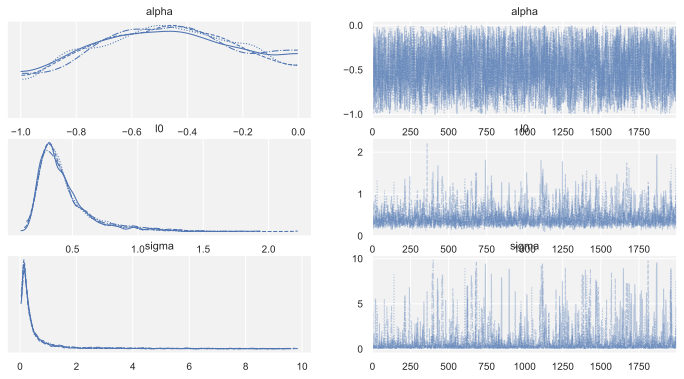

In [15]:
# 1) Text summary
trace = az.from_netcdf("Dataset/posterior_plus_ppc_full_rbf.nc")

print(az.summary(trace, var_names=["alpha", "l0", "sigma"]))

# 2) Trace plots (chains + mixing)
az.plot_trace(trace, var_names=["alpha", "l0", "sigma"])


### Fig 1

In [16]:
def kde_1d(samples, xmin=None, xmax=None, ngrid=400, bw="scott"):
    samples = np.asarray(samples)
    if xmin is None: xmin = samples.min()
    if xmax is None: xmax = samples.max()
    xs = np.linspace(xmin, xmax, ngrid)
    kde = gaussian_kde(samples, bw_method=bw)
    ys = kde(xs)
    return xs, ys

def kde_2d(x, y, xmin=None, xmax=None, ymin=None, ymax=None, ngrid=150, bw="scott"):
    x = np.asarray(x); y = np.asarray(y)
    if xmin is None: xmin = x.min()
    if xmax is None: xmax = x.max()
    if ymin is None: ymin = y.min()
    if ymax is None: ymax = y.max()

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, ngrid),
        np.linspace(ymin, ymax, ngrid)
    )
    kde = gaussian_kde(np.vstack([x, y]), bw_method=bw)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    return xx, yy, zz

def plot_fig1(trace, bw1="scott", bw2="scott", ngrid1=400, ngrid2=150, figsize=(15,12), cb_ranges=None, cmap="viridis", levels=5):
    """
    Rebuild Fig 1:
      left: 1D KDEs for alpha, l0, sigma
      right: 2D KDEs (l0 vs sigma), (l0 vs alpha), (sigma vs alpha)
    """

    # ---- extract samples from trace (works for PyMC InferenceData)
    alpha = trace.posterior["alpha"].values.ravel()
    l0    = trace.posterior["l0"].values.ravel()
    sigma = trace.posterior["sigma"].values.ravel()

    print("alpha: ", np.max(alpha), np.min(alpha))
    print("l0: ", np.max(l0), np.min(l0))
    print("sigma: ", np.max(sigma), np.min(sigma))

    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # ---------------- LEFT COLUMN: 1D KDEs ----------------
    # alpha
    ax = axes[0,0]
    xs, ys = kde_1d(alpha, xmin=-0.9, xmax=0.0, ngrid=ngrid1, bw=bw1)
    ax.plot(xs, ys, lw=2, label=r"$\alpha$ posterior")
    ax.set_xlim(-0.9, 0.0)
    ax.set_ylim(0.0, 2.0)
    ax.set_xlabel(r"$\alpha$")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.5)

    # l0
    ax = axes[1,0]
    xs, ys = kde_1d(l0, xmin=0.0, xmax=10.0, ngrid=ngrid1, bw=bw1)
    ax.plot(xs, ys, lw=2, label=r"$l$ posterior")
    ax.set_xlim(0.0, 10.0)
    # ax.set_ylim(0.0, 1.)
    ax.set_xlabel(r"$l$")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.5)

    # sigma
    ax = axes[2,0]
    xs, ys = kde_1d(sigma, xmin=0.0, xmax=10.0, ngrid=ngrid1, bw=bw1)
    ax.plot(xs, ys, lw=2, label=r"$\sigma$ posterior")
    ax.set_xlim(0.0, 10.0)
    ax.set_ylim(0.0, 2.0)
    ax.set_xlabel(r"$\sigma$")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.5)

    # ---------------- RIGHT COLUMN: 2D KDEs ----------------
    def contour_panel(ax, x, y, key, xmin, xmax, ymin, ymax, xlabel, ylabel):
        xx, yy, zz = kde_2d(x, y, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                            ngrid=ngrid2, bw=bw2)

        # pick vmin/vmax from cb_ranges if provided, else use zz min/max
        if cb_ranges and key in cb_ranges:
            vmin, vmax = cb_ranges[key]
        else:
            vmin, vmax = float(zz.min()), float(zz.max())

        # norm = Normalize(vmin=vmin, vmax=vmax)
        cs = ax.contourf(xx, yy, zz, levels=levels, cmap=cmap) #, norm=norm)

        cbar = fig.colorbar(cs, ax=ax)
        cbar.set_ticks(np.linspace(vmin, vmax, levels))  # like your screenshot

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.5)

    # top-right: l0 vs sigma
    contour_panel(
        axes[0,1],
        sigma, l0,
        key="l0_sigma",
        xmin=0.0, xmax=2.0, ymin=0.0, ymax=2.0,
        xlabel=r"$\sigma$", ylabel=r"$l$"
    )

    # mid-right: l0 vs alpha
    contour_panel(
        axes[1,1],
        alpha, l0,
        key="l0_alpha",
        xmin=-0.9, xmax=0.0, ymin=0.0, ymax=10.0,
        xlabel=r"$\alpha$", ylabel=r"$l$"
    )

    # bottom-right: sigma vs alpha
    contour_panel(
        axes[2,1],
        alpha, sigma,
        key="sigma_alpha",
        xmin=-0.9, xmax=0.0, ymin=0.0, ymax=10.0,
        xlabel=r"$\alpha$", ylabel=r"$\sigma$"
    )

    plt.tight_layout()
    return fig, axes
    


alpha:  -0.0007657487326408847 -0.9987090713321326
l0:  2.460905357055318 0.12079691319135027
sigma:  9.82327505245912 0.025889865321076046


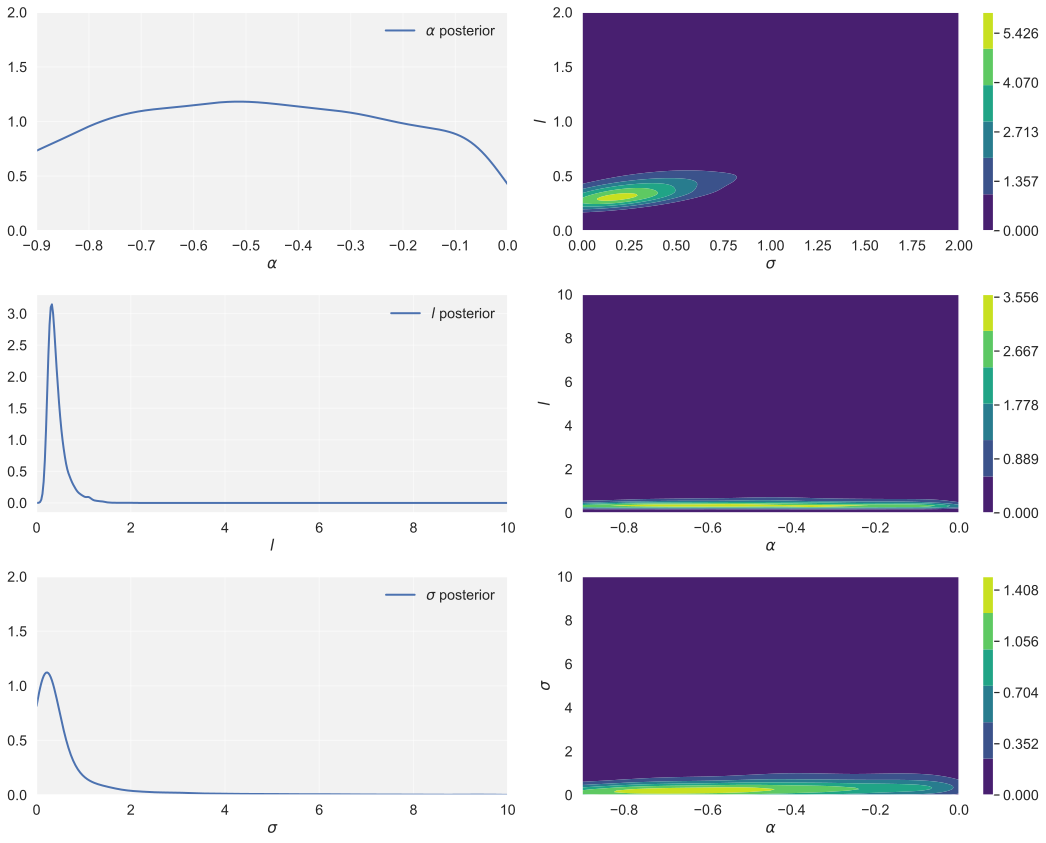

In [32]:
# cb_ranges = {
#     "l0_sigma":    (0.02, 0.4),
#     "l0_alpha":    (0.02, 0.25),
#     "sigma_alpha": (0.28,  6.50),
# }

fig, axes = plot_fig1(trace, bw1=0.2, bw2=0.2)
plt.savefig('rbf_t3_tests.pdf')
plt.show()

### Fig 2

- GP posterior on $f^*$ and $x^*$
- get replicas from $x^*$
- Do NUTS again?

In [ ]:
def posterior_fstar(theta, FK=W, CY=c_yy, y=y_pseudo):

    alpha, l0, sigma2 = theta

    kern = RBFKernel1D(alpha=alpha, ell=l0, sigma2=sigma2)

    Kxx   = kern(X_train)                 # (N, N)
    Ksx   = kern(X_star,  X_train)        # (N*, N)  == K_{x* x}
    Kxs   = kern(X_train,  X_star)        # (N, N*)  == K_{x x*}
    Kss   = kern(X_star,  X_star)         # (N*, N*)  == K_{x* x*}

    CYT = FK @ Kxx @ FK.T + CY
    CYT = CYT + 1e-10*np.eye(CYT.shape[0])
    L = cholesky(CYT)

    def solve_CYT(b):
        v = solve(L, b)
        return solve(L.T, v)

    # mean
    v = solve_CYT(y)   # CYT^{-1} y
    
    #mstar = mstar_tilde, set mstar = 0                 
    m_star = Ksx @ FK.T @ v            # (N*,)
    m_star = 0.5*(m_star + m_star.T)

    # covariance
    A = solve_CYT(FK @ Ksx.T)          # CYT^{-1}(FK Kxs)  shape (Ndat, N*)
    K_star = Kss - Ksx @ FK.T @ A      # (N*, N*)

    # symmetrize tiny numerical asymmetry
    K_star = 0.5*(K_star + K_star.T)

    return m_star, K_star

In [19]:
replicas = []
means = []

# trace = az.from_netcdf("Dataset/posterior_plus_ppc_full.nc")

alpha_s = trace.posterior["alpha"].values.ravel()
l0_s    = trace.posterior["l0"].values.ravel()
sigma2_s= trace.posterior["sigma2"].values.ravel()

theta_samples = np.stack([alpha_s, l0_s, sigma2_s], axis=1)

print(len(theta_samples))
print(theta_samples)
i=0
for theta in theta_samples:
    m_star, K_star = posterior_fstar(theta)
    f_star = np.random.multivariate_normal(m_star, K_star)
    replicas.append(f_star)
    means.append(m_star)
    i+=1
    if (i % 100) == 0: print(i)


replicas = np.asarray(replicas)   # (S, N*)
means    = np.asarray(means)


8000
[[-0.32029551  0.32958879  0.09837723]
 [-0.52807431  0.48288296  0.07420961]
 [-0.52910427  0.42409004  0.353941  ]
 ...
 [-0.3572871   0.51422495  0.55719177]
 [-0.26502193  0.5512271   1.59836785]
 [-0.66453394  0.52834468  0.17643037]]


/var/folders/gn/5m9p5_pd4677y7ff0wpgdhyc0000gn/T/ipykernel_21707/3351031460.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  f_star = np.random.multivariate_normal(m_star, K_star)


100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000


(400,)
(8000, 400)
[-4.22922934e+08 -1.47297771e+00 -8.30583409e-01 -5.81258210e-01
 -4.42054641e-01 -3.50484479e-01 -2.84263655e-01 -2.33317974e-01
 -1.92378191e-01 -1.58399232e-01 -1.29488365e-01 -1.04401749e-01
 -8.22851953e-02 -6.25307983e-02 -4.46929624e-02 -2.84368543e-02
 -1.35054844e-02  3.02028897e-04  1.31452302e-02  2.51526202e-02
  3.64289880e-02  4.70607365e-02  5.71198188e-02  6.66666928e-02
  7.57525714e-02  8.44211567e-02  9.27099938e-02  1.00651538e-01
  1.08274004e-01  1.15602049e-01  1.22657328e-01  1.29458942e-01
  1.36023810e-01  1.42366980e-01  1.48501881e-01  1.54440543e-01
  1.60193770e-01  1.65771302e-01  1.71181940e-01  1.76433661e-01
  1.81533709e-01  1.86488686e-01  1.91304613e-01  1.95987003e-01
  2.00540907e-01  2.04970967e-01  2.09281455e-01  2.13476308e-01
  2.17559168e-01  2.21533400e-01  2.25402129e-01  2.29168252e-01
  2.32834467e-01  2.36403285e-01  2.39877052e-01  2.43257958e-01
  2.46548054e-01  2.49749263e-01  2.52863389e-01  2.55892132e-01
  2.58

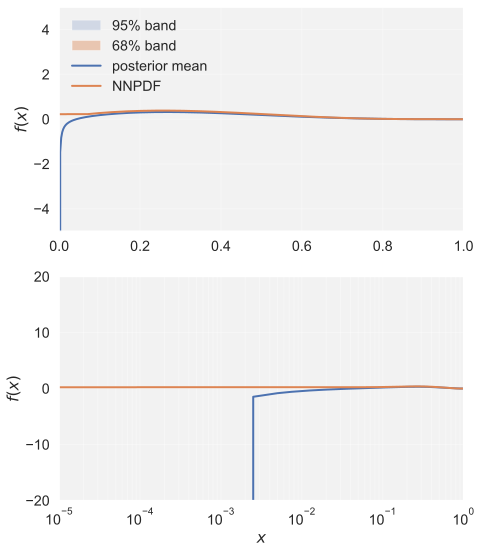

In [21]:
mean_curve = means.mean(axis=0)
print(mean_curve.shape)
print(means.shape)
lo68, hi68 = np.percentile(replicas, [16, 84], axis=0)
lo95, hi95 = np.percentile(replicas, [2.5, 97.5], axis=0)

xt3_true_star = np.interp(x_star, xgrid, f0_vals)

print(mean_curve)
print("--------")
print(lo68)
print("--------")
print(hi68)
# ------------------------------------------
# 6) PLOT FIG 2 (two panels)
# ------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# ---- top: linear x
ax = axes[0]
ax.fill_between(x_star, lo95, hi95, alpha=0.2, label="95% band")
ax.fill_between(x_star, lo68, hi68, alpha=0.4, label="68% band")
ax.plot(x_star, mean_curve, lw=2, label="posterior mean")
ax.plot(x_star, xt3_true_star, lw=2, label="NNPDF")

# plot a few replicas lightly
# for k in range(min(30, replicas.shape[0])):
#     ax.plot(x_star, replicas[k], alpha=0.1, lw=1)

ax.set_ylabel(r"$f(x)$")
ax.set_xlim([0, 1.0])
ax.set_ylim([-5.0, 5.0])
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# ---- bottom: log-x view (like paper)
ax = axes[1]
ax.fill_between(x_star, lo95, hi95, alpha=0.2)
ax.fill_between(x_star, lo68, hi68, alpha=0.4)
ax.plot(x_star, mean_curve, lw=2)
ax.plot(x_star, xt3_true_star, lw=2, label="NNPDF")

ax.set_xscale("log")
ax.set_xlim([1e-5, 1.0])
ax.set_ylim([-20.0, 20.0])
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("mean_pred_rbf_t3.pdf")
plt.show()
